In [2]:
from sklearn.datasets import load_breast_cancer
import numpy as np
import pandas as pd
breast_cancer = load_breast_cancer()

In [3]:
df = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
df["target"] = breast_cancer.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
print(df.describe())
print(df.shape)

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

In [6]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

In [ ]:
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [ ]:
data = df[df.columns[:-1]]
target = df["target"]
print(data)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean concavity  mean concave points  mea

In [ ]:
from sklearn.model_selection import train_test_split

train_x,test_x,train_y,test_y = train_test_split(data,target,test_size=0.2,random_state=42,stratify=target)

In [ ]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_x)
train_scaled = ss.transform(train_x)
test_scaled = ss.transform(test_x)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

lr = LogisticRegression()
kn = KNeighborsClassifier()
dt = DecisionTreeClassifier()

lr.fit(train_scaled,train_y)
kn.fit(train_scaled,train_y)
dt.fit(train_scaled,train_y)

lr.predict(test_scaled)
kn.predict(test_scaled)
dt.predict(test_scaled)

print(lr.score(test_scaled,test_y))
print(kn.score(test_scaled,test_y))
print(dt.score(test_scaled,test_y))



0.9824561403508771
0.956140350877193
0.9035087719298246


In [ ]:
from sklearn.model_selection import cross_val_score

lrcv = cross_val_score(lr,train_scaled,train_y,cv = 5)
dtcv = cross_val_score(dt,train_scaled,train_y,cv = 5)
kncv = cross_val_score(kn,train_scaled,train_y,cv = 5)
print(lrcv)
print(dtcv)
print(kncv)


[0.96703297 0.97802198 0.96703297 1.         0.98901099]
[0.93406593 0.87912088 0.91208791 0.92307692 0.93406593]
[0.94505495 1.         0.94505495 0.97802198 0.96703297]


Text(0.5, 1.0, '모델 별 유방암 분류')

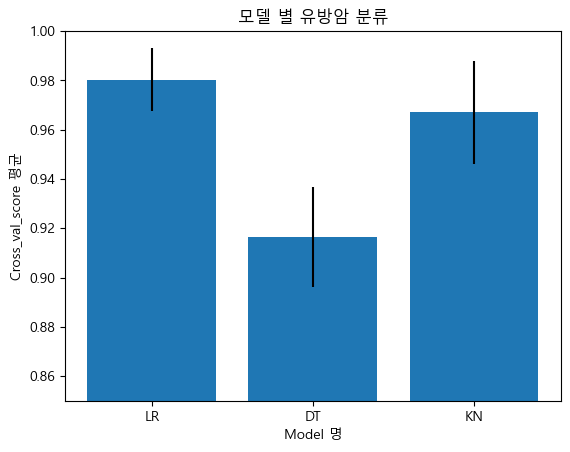

In [ ]:
import matplotlib.pyplot as plt

names = ["LR","DT","KN"]
means = [lrcv.mean(),dtcv.mean(),kncv.mean()]
stds = [lrcv.std(),dtcv.std(),kncv.std()]
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.bar(names,means,yerr=stds)
plt.ylim(0.85,1.0)
plt.xlabel("Model 명")
plt.ylabel("Cross_val_score 평균")
plt.title("모델 별 유방암 분류")

In [ ]:
from sklearn.model_selection import GridSearchCV
params = {"C":[0.01, 0.1, 1, 10, 100], "solver" : ['lbfgs', 'liblinear']}
gs = GridSearchCV(LogisticRegression(random_state=42),params,cv=5)
gs.fit(train_scaled,train_y)

lr = gs.best_estimator_
print(lr.score(train_scaled,train_y))
print(gs.best_params_)

0.9868131868131869
{'C': 0.1, 'solver': 'lbfgs'}


In [ ]:
from sklearn.metrics import confusion_matrix,classification_report

pred = lr.predict(test_scaled) 
cm = confusion_matrix(test_y,pred)
print(cm)

cr = classification_report(test_y,pred)
print(cr)

[[40  2]
 [ 1 71]]
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        42
           1       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

